In [1]:
# ejecutar esta celda para instalar las librerías necesarias
# %pip install pandas numpy matplotlib scikit-learn

# Predicción de salarios con aprendizaje automatico

En este notebook abordamos un problema de regresión: estimar el salario de una persona a partir de variables como puesto, experiencia, nivel educativo, sector, tamaño de empresa o modalidad de trabajo.

La idea es seguir un flujo completo y claro: revisar datos, preprocesar, comparar varios modelos, ajustar el modelo final e interpretar que variables estan influyendo mas en la predicción.

El foco de la práctica no es solo obtener una métrica alta, sino justificar cada decisión del proceso y documentar resultados de forma reproducible.

## 1. Importación de librerías

El primer paso siempre es la importación de las librerías que vamos a hacer uso durante el cuaderno.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Preprocesamiento y validacion
from sklearn.model_selection import train_test_split, RandomizedSearchCV, cross_validate, KFold
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

# Algoritmos de regresion
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.neighbors import KNeighborsRegressor

# Metricas
from sklearn.metrics import mean_squared_error, r2_score

import warnings
warnings.filterwarnings('ignore')

import random

## 2. Carga y revisión inicial del dataset

En este paso cargamos el dataset completo y hacemos una revisión rápida para comprobar que todo esta en orden antes de entrenar modelos.

Concretamente revisamos:
- dimensiones del conjunto de datos,
- tipo de cada variable,
- valores nulos por columna,
- filas duplicadas,
- resumen estadístico de salary.

Como los datos ya vienen limpios, evitamos transformaciones innecesarias y mantenemos el flujo lo mas directo posible.

In [3]:
df = pd.read_csv('job_salary_prediction_dataset.csv')

print('Dimensiones:', df.shape)
print('\nTipos de datos:')
print(df.dtypes)
print('\nValores nulos por columna:')
print(df.isna().sum())
print('\nFilas duplicadas:', df.duplicated().sum())
print('\nResumen de la variable objetivo salary:')
print(df['salary'].describe())

df.head()

Dimensiones: (250000, 10)

Tipos de datos:
job_title             str
experience_years    int64
education_level       str
skills_count        int64
industry              str
company_size          str
location              str
remote_work           str
certifications      int64
salary              int64
dtype: object

Valores nulos por columna:
job_title           0
experience_years    0
education_level     0
skills_count        0
industry            0
company_size        0
location            0
remote_work         0
certifications      0
salary              0
dtype: int64

Filas duplicadas: 0

Resumen de la variable objetivo salary:
count    250000.000000
mean     145718.080524
std       37407.952729
min       31867.000000
25%      119358.000000
50%      143453.000000
75%      169492.000000
max      333046.000000
Name: salary, dtype: float64


,job_title,experience_years,education_level,skills_count,industry,company_size,location,remote_work,certifications,salary
0,AI Engineer,10,Bachelor,2,Healthcare,Medium,India,Hybrid,2,109413
1,Data Analyst,5,Bachelor,17,Telecom,Small,Australia,No,0,93764
2,Frontend Developer,18,PhD,4,Media,Medium,Singapore,No,1,148123
3,Business Analyst,19,PhD,13,Retail,Medium,Canada,Yes,0,189123
4,Product Manager,15,Bachelor,7,Manufacturing,Large,Sweden,Yes,0,165069


## 3. Exploración visual del dataset

En esta sección no buscamos entrenar nada todavía, solo entender mejor los datos antes de modelar.

Revisamos tres aspectos útiles para orientar el trabajo posterior:
- como se distribuye salary,
- como se reparte experience_years,
- y como cambian los salarios segun modalidad de trabajo y puesto.

Este análisis inicial ayuda a detectar patrones y posibles sesgos, dándonos contexto para interpretar mejor los resultados de los modelos.

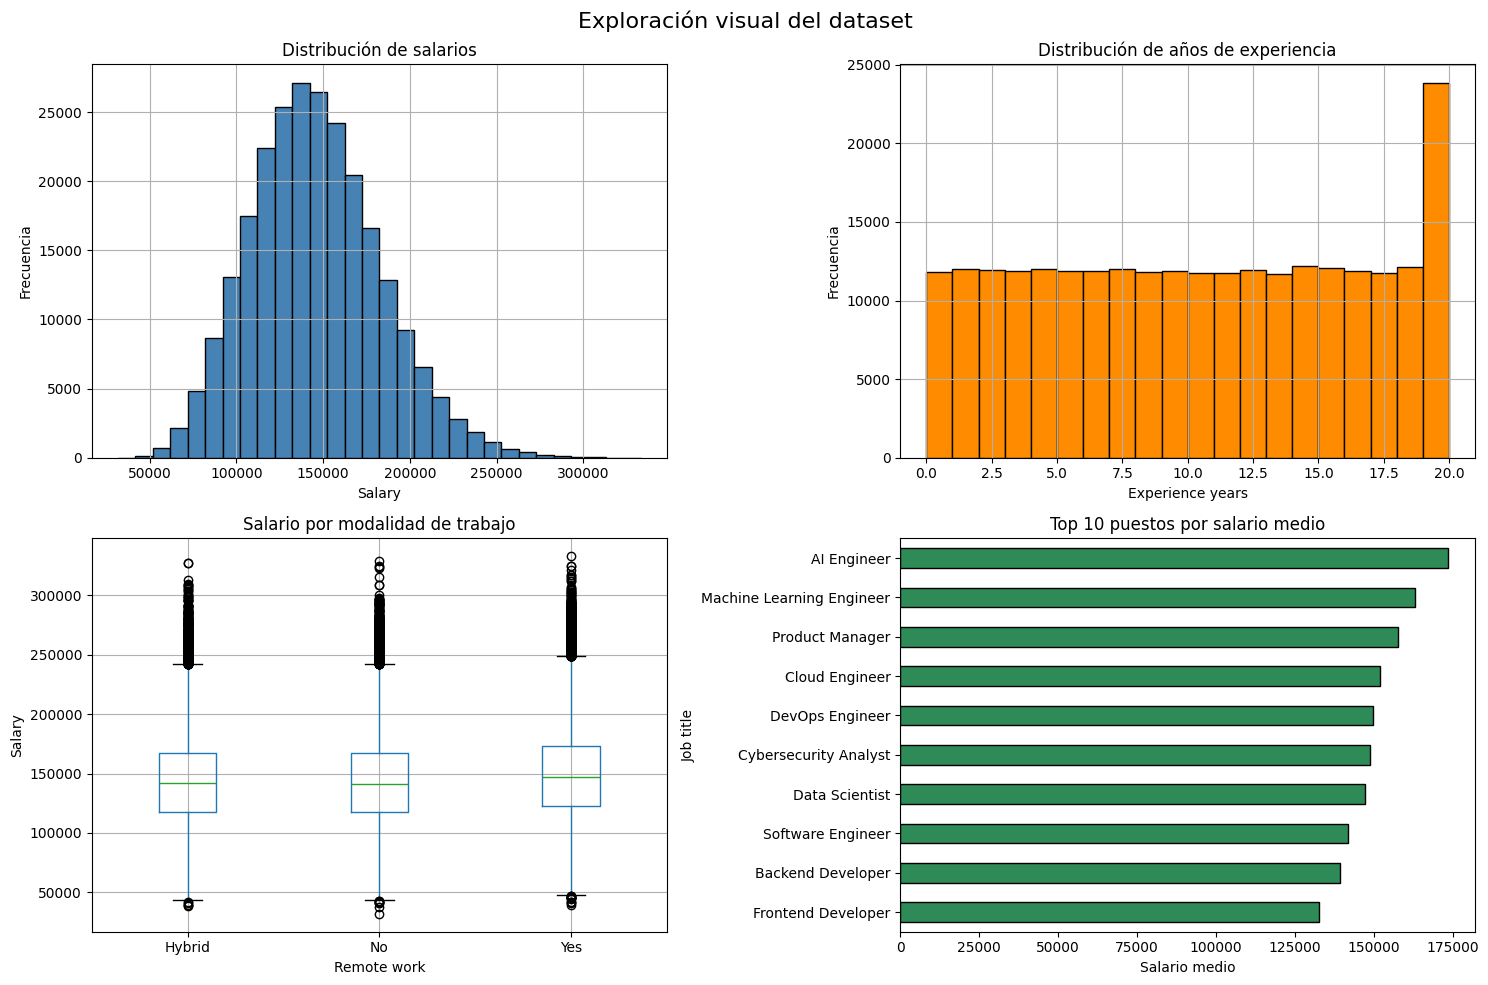

,count,mean,median
remote_work,,,
Yes,82903,149279.59,147153.0
Hybrid,83476,143969.90,141672.0
No,83621,143932.30,141630.0


In [4]:
if 'df' not in globals():
    df = pd.read_csv('job_salary_prediction_dataset.csv')

fig, axes = plt.subplots(2, 2, figsize=(15, 10))

df['salary'].hist(bins=30, ax=axes[0, 0], color='steelblue', edgecolor='black')
axes[0, 0].set_title('Distribución de salarios')
axes[0, 0].set_xlabel('Salary')
axes[0, 0].set_ylabel('Frecuencia')

df['experience_years'].hist(bins=20, ax=axes[0, 1], color='darkorange', edgecolor='black')
axes[0, 1].set_title('Distribución de años de experiencia')
axes[0, 1].set_xlabel('Experience years')
axes[0, 1].set_ylabel('Frecuencia')

df.boxplot(column='salary', by='remote_work', ax=axes[1, 0])
axes[1, 0].set_title('Salario por modalidad de trabajo')
axes[1, 0].set_xlabel('Remote work')
axes[1, 0].set_ylabel('Salary')

top_roles = df.groupby('job_title')['salary'].mean().sort_values(ascending=False).head(10)
top_roles.sort_values().plot(kind='barh', ax=axes[1, 1], color='seagreen', edgecolor='black')
axes[1, 1].set_title('Top 10 puestos por salario medio')
axes[1, 1].set_xlabel('Salario medio')
axes[1, 1].set_ylabel('Job title')

plt.suptitle('Exploración visual del dataset', fontsize=16)
plt.tight_layout()
plt.show()

display(
    df.groupby('remote_work')['salary']
    .agg(['count', 'mean', 'median'])
    .sort_values(by='mean', ascending=False)
    .round(2)
)

## 4. Preprocesamiento y división de datos

En esta fase dejamos preparado todo el flujo de trabajo antes de entrenar modelos.

Primero separamos la variable objetivo (`salary`) del resto de columnas predictoras. Despues dividimos el dataset en entrenamiento y test (80/20). El conjunto de test se guarda para la evaluación final y no se usa durante el ajuste de modelos.

Sobre el entrenamiento, usamos validación cruzada con 2 folds (`KFold`). Eso significa que, dentro de `X_train`, se hacen dos particiones para validar el modelo sin tocar `X_test`.
- En cada fold se ajusta el preprocesado y el modelo con la parte de entrenamiento de ese fold.
- Luego se transforma/predice la parte de validacion del fold.
- Al final se promedian métricas (por ejemplo R2 y MSE) para estimar rendimiento estable.

### Flujo completo que seguimos

1. `train_test_split`: separa entrenamiento y test final.
2. Definición del `preprocessor` (imputacion + escalado numérico + one-hot en categóricas).
3. Validación cruzada sobre entrenamiento para comparar modelos.
4. Entrenamiento del modelo elegido con todo `X_train`.
5. Evaluación final una sola vez en `X_test`.

Este enfoque evita fuga de información y permite una comparación justa entre modelos.

In [ ]:
# Variables predictoras y variable objetivo
X = df.drop('salary', axis=1)
y = df['salary']

# Columnas numéricas y categóricas
cat_cols = X.select_dtypes(include=['object']).columns
num_cols = X.select_dtypes(exclude=['object']).columns

# Pipelines para preprocesamiento
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='infrequent_if_exist', min_frequency=20))
])

# Combinamos los transformadores en un ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, num_cols),
        ('cat', categorical_transformer, cat_cols)
    ]
)

# Dividimos el dataset en entrenamiento y prueba (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Usamos 2 folds para reducir tiempos de cómputo manteniendo validación cruzada
cv_strategy = KFold(n_splits=2, shuffle=True, random_state=42)

print(f'Muestras para entrenar: {X_train.shape[0]}')
print(f'Muestras para validar: {X_test.shape[0]}')
print(f'Número de variables numéricas: {len(num_cols)}')
print(f'Número de variables categóricas: {len(cat_cols)}')

Muestras para entrenar: 200000
Muestras para validar: 50000
Número de variables numéricas: 3
Número de variables categóricas: 6


## 5. Comprobación del preprocesado

Antes de entrenar y comparar modelos, hacemos una verificación rápida para confirmar que el preprocesado esta funcionando como esperamos.

En esta comprobación ajustamos el `preprocessor` con `X_train` y transformamos también `X_test` con ese mismo ajuste. Así validamos dos cosas importantes:
- que todas las variables quedan en formato numérico,
- y que la dimensionalidad final tras el one-hot encoding es coherente.

Este paso sirve para detectar errores pronto (como columnas mal tipadas o cambios inesperados en categorías) y para documentar que el flujo de transformación se aplica correctamente antes del entrenamiento.

In [6]:
X_train_transformed = preprocessor.fit_transform(X_train)
X_test_transformed = preprocessor.transform(X_test)

print('Forma del conjunto de entrenamiento tras el preprocesado:', X_train_transformed.shape)
print('Forma del conjunto de prueba tras el preprocesado:', X_test_transformed.shape)
print('Número total de variables generadas:', len(preprocessor.get_feature_names_out()))

feature_names = preprocessor.get_feature_names_out()
print('\nPrimeras 15 variables transformadas:')
print(feature_names[:15])

Forma del conjunto de entrenamiento tras el preprocesado: (200000, 48)
Forma del conjunto de prueba tras el preprocesado: (50000, 48)
Número total de variables generadas: 48

Primeras 15 variables transformadas:
['num__experience_years' 'num__skills_count' 'num__certifications'
 'cat__job_title_AI Engineer' 'cat__job_title_Backend Developer'
 'cat__job_title_Business Analyst' 'cat__job_title_Cloud Engineer'
 'cat__job_title_Cybersecurity Analyst' 'cat__job_title_Data Analyst'
 'cat__job_title_Data Scientist' 'cat__job_title_DevOps Engineer'
 'cat__job_title_Frontend Developer'
 'cat__job_title_Machine Learning Engineer'
 'cat__job_title_Product Manager' 'cat__job_title_Software Engineer']


## 6. Entrenamiento y comparación de modelos

En esta parte entrenamos varios modelos de regresión con el mismo pipeline de preprocesado para que la comparación sea justa. Para mantener un equilibrio entre calidad y tiempo de ejecución, usamos validación cruzada de 2 folds sobre entrenamiento y dejamos el conjunto de test para la evaluación final.

### Nota sobre `n_jobs`

- `n_jobs=-1`: usa todos los núcleos disponibles de la CPU.
- `n_jobs=1`: ejecuta en un único núcleo.

En este cuaderno lo aplicamos asi:
- En `KNN` y `Random Forest`, `n_jobs=-1` para acelerar el entrenamiento del propio modelo.
- En `cross_validate`, `n_jobs=1` para evitar paralelismo anidado (muchos procesos por fuera y por dentro al mismo tiempo), que en datasets grandes suele penalizar el rendimiento.
- En `RandomizedSearchCV`, `n_jobs=-1` para acelerar la búsqueda de hiperparámetros.

### Por qué no incluimos SVR (SVM para regresión)

Aunque SVR es un método válido para regresión, en este caso no era una buena opción práctica:
- El dataset tiene 250.000 filas, y SVR con kernels no lineales escala mal en tiempo y memoria con ese volumen.
- Tras el one-hot encoding se generan muchas variables, lo que incrementa aun más el coste de entrenamiento.
- El objetivo de esta práctica era comparar modelos representativos con coste computacional razonable en un entorno docente.

Por eso priorizamos modelos que mantienen buen rendimiento sin disparar tiempos de ejecución.

### Métricas usadas

- `R2` (`CV R2 medio` y `Test R2`): indica cuánta variabilidad del salario explica el modelo. Cuanto más cerca de 1, mejor.
- `MSE` (`CV MSE medio` y `Test MSE`): mide el error cuadrático medio; penaliza más los errores grandes.
- `CV R2 std`: muestra la estabilidad entre folds (valores bajos implican mayor consistencia).

Usamos `R2` y `MSE` de forma conjunta porque se complementan: una da una lectura relativa del ajuste y la otra una medida absoluta del error.

In [7]:
modelos = {
    '1. Regresion Lineal': LinearRegression(),
    '2. Ridge': Ridge(alpha=1.0),
    '3. K-Vecinos (KNN)': KNeighborsRegressor(n_neighbors=5, n_jobs=-1),
    '4. Random Forest': RandomForestRegressor(n_estimators=50, max_depth=15, random_state=42, n_jobs=-1),
    '5. Gradient Boosting': GradientBoostingRegressor(n_estimators=80, random_state=42)
}

resultados = []

for nombre, algoritmo in modelos.items():
    print(f'Entrenando {nombre}...')

    pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('model', algoritmo)
    ])

    cv_results = cross_validate(
        pipeline,
        X_train,
        y_train,
        cv=cv_strategy,
        scoring={'r2': 'r2', 'mse': 'neg_mean_squared_error'},
        # Aquí dejamos n_jobs=1 para evitar paralelismo anidado con modelos que ya usan n_jobs=-1.
        n_jobs=1
    )

    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)

    mse_test = mean_squared_error(y_test, y_pred)
    r2_test = r2_score(y_test, y_pred)

    resultados.append({
        'Modelo': nombre,
        'CV R2 medio': cv_results['test_r2'].mean(),
        'CV R2 std': cv_results['test_r2'].std(),
        # sklearn devuelve MSE negativa en scoring para mantener la convención de que mayor es mejor.
        'CV MSE medio': -cv_results['test_mse'].mean(),
        'Test R2': r2_test,
        'Test MSE': mse_test
    })

    print(
        f" -> CV R2 medio: {cv_results['test_r2'].mean():.4f} "
        f"(+/- {cv_results['test_r2'].std():.4f}) | "
        f"Test R2: {r2_test:.4f} | Test MSE: {mse_test:,.2f}\n"
    )

resultados_df = pd.DataFrame(resultados).sort_values(by='Test R2', ascending=False).reset_index(drop=True)
display(resultados_df)

print(f"Mejor modelo base según Test R2: {resultados_df.loc[0, 'Modelo']}")

Entrenando 1. Regresion Lineal...
 -> CV R2 medio: 0.9633 (+/- 0.0002) | Test R2: 0.9635 | Test MSE: 50,773,076.89

Entrenando 2. Ridge...
 -> CV R2 medio: 0.9633 (+/- 0.0002) | Test R2: 0.9635 | Test MSE: 50,772,652.46

Entrenando 3. K-Vecinos (KNN)...
 -> CV R2 medio: 0.8551 (+/- 0.0005) | Test R2: 0.8734 | Test MSE: 175,895,299.45

Entrenando 4. Random Forest...
 -> CV R2 medio: 0.9319 (+/- 0.0001) | Test R2: 0.9309 | Test MSE: 96,028,893.98

Entrenando 5. Gradient Boosting...
 -> CV R2 medio: 0.9283 (+/- 0.0004) | Test R2: 0.9283 | Test MSE: 99,655,083.84



,Modelo,CV R2 medio,CV R2 std,CV MSE medio,Test R2,Test MSE
0,2. Ridge,0.963342,0.000170,5.138483e+07,0.963469,5.077265e+07
1,1. Regresion Lineal,0.963342,0.000170,5.138472e+07,0.963469,5.077308e+07
2,4. Random Forest,0.931919,0.000113,9.543038e+07,0.930908,9.602889e+07
3,5. Gradient Boosting,0.928339,0.000417,1.004480e+08,0.928299,9.965508e+07
4,3. K-Vecinos (KNN),0.855126,0.000450,2.030731e+08,0.873444,1.758953e+08


Mejor modelo base según Test R2: 2. Ridge


## 7. Optimización de hiperparámetros

Después de comparar los modelos base, decidimos afinar Random Forest porque daba buen equilibrio entre precisión, estabilidad y facilidad para interpretar resultados.

No hemos hecho una búsqueda enorme de parámetros porque el objetivo de la práctica era obtener una mejora real sin disparar el tiempo de ejecución.

Para conseguir esto, usamos una búsqueda aleatoria pequeña y controlada:
- pocas combinaciones,
- pocos folds,
- paralelización para que termine en un tiempo razonable.

Con ese enfoque conseguimos mejorar el rendimiento respecto al Random Forest base y mantener el notebook ejecutable en un entorno normal.

In [8]:
param_distributions = {
    'model__n_estimators': [80, 120],
    'model__max_depth': [10, 20],
    'model__min_samples_split': [5, 10]
}

pipeline_rf = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', RandomForestRegressor(random_state=42, n_jobs=-1))
])

random_search = RandomizedSearchCV(
    estimator=pipeline_rf,
    param_distributions=param_distributions,
    n_iter=2,
    cv=cv_strategy,
    scoring='r2',
    random_state=42,
    n_jobs=-1  # Usamos todos los cores disponibles para acelerar la búsqueda.
)

print('Iniciando optimización de hiperparámetros para Random Forest...')
random_search.fit(X_train, y_train)

mejor_rf = random_search.best_estimator_
y_pred_rf = mejor_rf.predict(X_test)
mse_rf = mean_squared_error(y_test, y_pred_rf)
r2_rf = r2_score(y_test, y_pred_rf)

print(f'Mejores hiperparámetros encontrados:\n{random_search.best_params_}')
print(f'Mejor R2 medio en validación cruzada: {random_search.best_score_:.4f}')
print(f'R2 en test del modelo optimizado: {r2_rf:.4f}')
print(f'MSE en test del modelo optimizado: {mse_rf:,.2f}')

Iniciando optimización de hiperparámetros para Random Forest...
Mejores hiperparámetros encontrados:
{'model__n_estimators': 120, 'model__min_samples_split': 5, 'model__max_depth': 20}
Mejor R2 medio en validación cruzada: 0.9619
R2 en test del modelo optimizado: 0.9647
MSE en test del modelo optimizado: 49,001,810.70


## 8. Interpretabilidad del modelo final

Una vez elegido el modelo, analizamos que variables han tenido más peso en la prediccion.

Este análisis no demuestra causalidad, pero sí aporta una lectura útil de como esta tomando decisiones el modelo y que información considera más relevante.

En la práctica, nos sirve para responder una pregunta clave: además de predecir bien, ¿el modelo se comporta de forma coherente con el problema que estamos resolviendo?

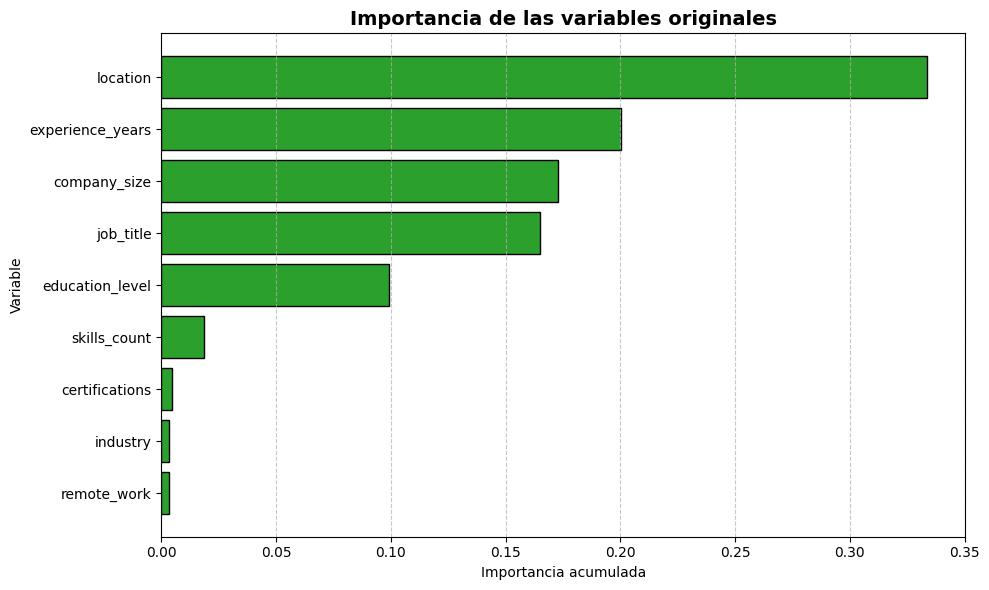

,Variable,Importancia
0,location,0.333479
1,experience_years,0.200047
2,company_size,0.172710
3,job_title,0.165042
4,education_level,0.099072
5,skills_count,0.018381
6,certifications,0.004729
7,industry,0.003445
8,remote_work,0.003095



Variables más influyentes en el modelo final:
 - location: 33.35% de importancia acumulada
 - experience_years: 20.00% de importancia acumulada
 - company_size: 17.27% de importancia acumulada
 - job_title: 16.50% de importancia acumulada
 - education_level: 9.91% de importancia acumulada


In [9]:
# Nombres de las variables tras el preprocesado
nombres_variables = mejor_rf.named_steps['preprocessor'].get_feature_names_out()

# Importancia de cada variable generada por el modelo
importancias = mejor_rf.named_steps['model'].feature_importances_
importancias_absolutas = {col: 0.0 for col in X.columns}

for nombre_completo, importancia in zip(nombres_variables, importancias):
    for col_original in X.columns:
        if f'num__{col_original}' == nombre_completo or nombre_completo.startswith(f'cat__{col_original}_'):
            importancias_absolutas[col_original] += importancia
            break

df_importancias = pd.DataFrame(
    list(importancias_absolutas.items()),
    columns=['Variable', 'Importancia']
).sort_values(by='Importancia', ascending=False).reset_index(drop=True)

top_importancias = df_importancias.head(10).sort_values(by='Importancia')

plt.figure(figsize=(10, 6))
plt.barh(top_importancias['Variable'], top_importancias['Importancia'], color='#2ca02c', edgecolor='black')
plt.title('Importancia de las variables originales', fontsize=14, fontweight='bold')
plt.xlabel('Importancia acumulada')
plt.ylabel('Variable')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

display(df_importancias.head(10))

print('\nVariables más influyentes en el modelo final:')
for _, fila in df_importancias.head(5).iterrows():
    print(f" - {fila['Variable']}: {fila['Importancia'] * 100:.2f}% de importancia acumulada")

## 9. Resultados y justificación de la solución

### Qué problema hemos resuelto
Se ha abordado un problema de regresión para estimar salary a partir de 9 variables de perfil profesional y contexto laboral. El dataset (250.000 filas) no presenta nulos ni duplicados, por lo que el flujo se ha centrado en preprocesado, modelado y evaluación.

### Resultados obtenidos
Con la comparación de modelos y la validación cruzada, el comportamiento general ha sido estable y alto en terminos de R2.

|         Modelo           | Test R2 |
|--------------------------|---------|
| Ridge / Regresion Lineal | 0.9635  |
| Random Forest (base)     | 0.9309  |
| Gradient Boosting        | 0.9283  |
| K-Vecinos (KNN)          | 0.8734  |

Tras optimizar Random Forest con búsqueda aleatoria, el resultado final fue:
- R2 en test: 0.9647
- Parámetros: n_estimators=120, max_depth=20, min_samples_split=5

### Justificación de la tecnología elegida
Aunque los modelos lineales también rinden muy bien, se elige Random Forest como solución final por tres motivos:
1. Mantiene una métrica excelente en test.
2. Permite interpretar importancias de variables de forma directa.
3. Se adapta mejor a relaciones no lineales y deja margen de mejora.

### Interpretación práctica de las predicciones
El modelo indica que las variables más influyentes son location, experience_years, company_size, job_title y education_level. Esto es muy coherente con el problema y puede aportar utilidad ya que no solo predice, también ayuda a entender que factores pesan más en la estimación salarial.

## 10. Demostración final del modelo

Para cerrar el trabajo, en la siguiente celda mostramos tres ejemplos reales del conjunto de test.

La idea es sencilla: comparar salario real frente a salario estimado y ver la diferencia absoluta y porcentual en casos concretos.

Con esta comprobación final podemos concluir que el modelo funciona sobre datos no vistos y las predicciones son interpretables caso a caso.

In [10]:
indices = random.sample(range(len(X_test)), 3)   # 3 filas aleatorias

print("=== PRUEBAS CON CASOS REALES (3 ejemplos) ===\n")

for i, idx in enumerate(indices, 1):
    X_ejemplo = X_test.iloc[[idx]]
    y_real = y_test.iloc[idx]
    y_pred = mejor_rf.predict(X_ejemplo)[0]
    
    dif_abs = abs(y_real - y_pred)
    dif_pct = (dif_abs / y_real) * 100   # error porcentual respecto al valor real
    
    print(f"--- Prueba {i} (índice {idx}) ---")
    print(X_ejemplo.to_string(index=False))
    print(f"Salario real:      {y_real:>12,.2f} €")
    print(f"Salario estimado:  {y_pred:>12,.2f} €")
    print(f"Diferencia (abs):  {dif_abs:>12,.2f} €")
    print(f"Diferencia (%):    {dif_pct:>11.2f} %")
    print()

=== PRUEBAS CON CASOS REALES (3 ejemplos) ===

--- Prueba 1 (índice 37079) ---
        job_title  experience_years education_level  skills_count industry company_size location remote_work  certifications
Software Engineer                 8             PhD             2  Telecom        Large   Remote         Yes               0
Salario real:        146,606.00 €
Salario estimado:    153,097.06 €
Diferencia (abs):      6,491.06 €
Diferencia (%):           4.43 %

--- Prueba 2 (índice 44975) ---
        job_title  experience_years education_level  skills_count  industry company_size location remote_work  certifications
Software Engineer                20         Diploma             1 Education      Startup       UK          No               0
Salario real:        145,990.00 €
Salario estimado:    152,217.24 €
Diferencia (abs):      6,227.24 €
Diferencia (%):           4.27 %

--- Prueba 3 (índice 31400) ---
      job_title  experience_years education_level  skills_count   industry company_